**Exploring the socioeconomic variables**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('owid-covid-data.csv')

Which countries are represented?

In [3]:
df['location'].unique()

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Asia', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guine

We see that there are two locations labeled "European Union (27)" and "World." The data for these locations is likely aggregated from all countries belonging to those categories. We may want to drop these rows to focus on individual countries.

Some socioeconomic variables that seem of interest:

In [4]:
cols = ['population_density', 'aged_65_older', 'gdp_per_capita', 'extreme_poverty', 'female_smokers', 'male_smokers', 'handwashing_facilities', 'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index']

How often is the measurement of each variable updated for each country? In other words, how many unique values of each variable are recorded for each country?

In [5]:
df_counts = df.groupby('location')[cols].nunique().reset_index()
#Exclude "European Union (27)" and "World" locations
df_counts = df_counts[~df_counts['location'].isin(['European Union (27)', 'World'])]
df_counts

,location,population_density,aged_65_older,gdp_per_capita,extreme_poverty,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,Afghanistan,1,1,1,0,0,0,1,1,1,1
1,Africa,0,0,0,0,0,0,0,0,0,0
2,Albania,1,1,1,1,1,1,0,1,1,1
3,Algeria,1,1,1,1,1,1,1,1,1,1
4,American Samoa,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
249,Wallis and Futuna,0,0,0,0,0,0,0,0,1,0
250,Western Sahara,0,0,0,0,0,0,0,0,1,0
252,Yemen,1,1,1,1,1,1,1,1,1,1
253,Zambia,1,1,1,1,1,1,1,1,1,1


In [6]:
for col in cols:
    print(col, df_counts[col].unique())

population_density [1 0]
aged_65_older [1 0]
gdp_per_capita [1 0]
extreme_poverty [0 1]
female_smokers [0 1]
male_smokers [0 1]
handwashing_facilities [1 0]
hospital_beds_per_thousand [1 0]
life_expectancy [1 0]
human_development_index [1 0]


We see that each variable has at one measurement recorded for each country. For some variables and countries, there is no measurement, only NaN.

For how many countries is each variable recorded?

In [7]:
df_counts[cols].sum()

population_density            214
aged_65_older                 192
gdp_per_capita                195
extreme_poverty               125
female_smokers                146
male_smokers                  144
handwashing_facilities         95
hospital_beds_per_thousand    172
life_expectancy               233
human_development_index       189
dtype: int64

We see that many countries do not have handwashing_facilities or extreme_poverty recorded.

For how many countries in the top 10 by GDP is each variable recorded?

In [8]:
#The top 10 countries in the world by GDP (according to Wikipedia):
top_10_gdp = ['United States', 'China', 'Germany', 'Japan', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil']
df_top10 = df_counts[df_counts['location'].isin(top_10_gdp)]
df_top10[cols].sum()

population_density            10
aged_65_older                 10
gdp_per_capita                10
extreme_poverty                7
female_smokers                10
male_smokers                  10
handwashing_facilities         1
hospital_beds_per_thousand    10
life_expectancy               10
human_development_index       10
dtype: int64

In [9]:
df_top10[['location', 'handwashing_facilities']]

,location,handwashing_facilities
30,Brazil,0
44,China,0
77,France,0
83,Germany,0
102,India,1
109,Italy,0
111,Japan,0
187,Russia,0
238,United Kingdom,0
239,United States,0


In [10]:
df_top10[['location', 'extreme_poverty']]

,location,extreme_poverty
30,Brazil,1
44,China,1
77,France,0
83,Germany,0
102,India,1
109,Italy,1
111,Japan,0
187,Russia,1
238,United Kingdom,1
239,United States,1


We see that only India has measurements of handwashing facilities, while France, Germany, and Japan are missing measurements of extreme poverty. We may want to exclude these variables to ensure that every variable we keep at least has measurements for the top 10 countries in the world by GDP.

If we only keep countries that have measurements of every variable except handwashing facilities and extreme poverty, how many countries are left?

In [11]:
df_counts_new = df_counts.drop(columns = ['handwashing_facilities', 'extreme_poverty'])
df_counts_new = df_counts_new[(df_counts_new != 0).all(axis=1)]
countries_kept = list(df_counts_new['location'])

In [12]:
print(countries_kept)

['Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Benin', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Canada', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Comoros', 'Costa Rica', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt', 'El Salvador', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Haiti', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Liberia', 'Lithuania', 'Luxembourg', 'Malawi', 'Malaysia', 'Mali', 'Malta', 'Mauritius', 'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Nepal', 'Netherlands', 'New Zealan

In [13]:
print(len(countries_kept))

129


We see that there are 129 countries left, including the top 10 countries by GDP.

If we only keep the variables mentioned above and we only keep countries for which all variables are recorded, what do the correlations between variables look like? What about the correlations between the variables and total deaths per million?

In [14]:
#Variables that we decided not to drop
newcols = ['population_density', 'aged_65_older', 'gdp_per_capita', 'female_smokers', 'male_smokers', 'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index']
df_vars = df.drop_duplicates(subset = 'location', keep = 'last')[['location'] + ['total_deaths_per_million'] + newcols]
df_vars = df_vars[df_vars['location'].isin(countries_kept)]
df_vars

,location,total_deaths_per_million,population_density,aged_65_older,gdp_per_capita,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index
5021,Albania,1274.93,104.87,13.19,11803.43,7.1,51.2,2.89,78.57,0.80
6695,Algeria,151.31,17.35,6.21,13913.84,0.7,30.4,1.90,76.88,0.75
16743,Argentina,2877.54,16.18,11.20,18933.91,16.2,27.7,5.00,76.67,0.84
18417,Armenia,3046.64,102.93,11.23,8787.58,1.5,52.1,4.20,75.09,0.78
23449,Australia,963.17,3.20,15.50,44648.71,13.0,16.5,3.84,83.44,0.94
...,...,...,...,...,...,...,...,...,...,...
413159,Uzbekistan,29.08,76.13,4.47,6253.10,1.3,24.7,4.00,71.72,0.72
419855,Vietnam,433.44,308.13,7.15,6171.88,1.0,45.9,2.60,75.40,0.70
426086,Yemen,56.48,53.51,2.92,1479.15,7.6,29.2,0.70,66.12,0.47
427760,Zambia,202.30,23.00,2.48,3689.25,3.1,24.7,2.00,63.89,0.58


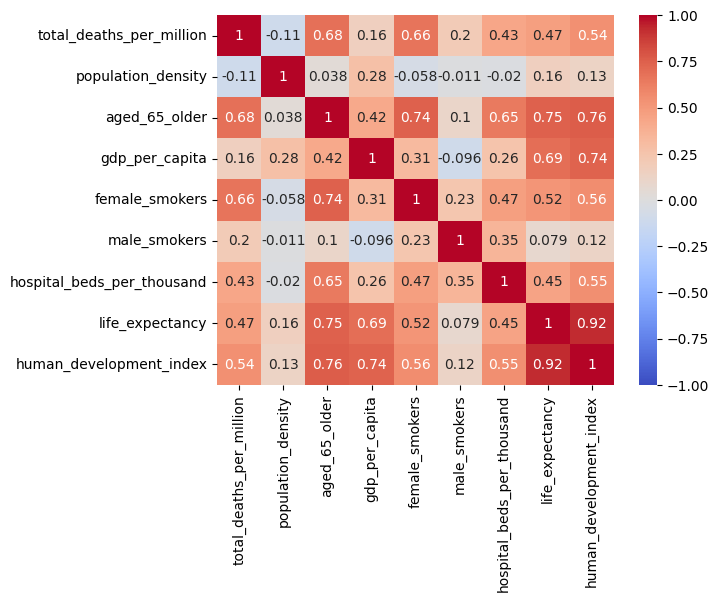

In [15]:
sns.heatmap(df_vars[['total_deaths_per_million'] + newcols].corr(), vmin = -1, vmax = 1, annot = True, cmap = 'coolwarm')
pass

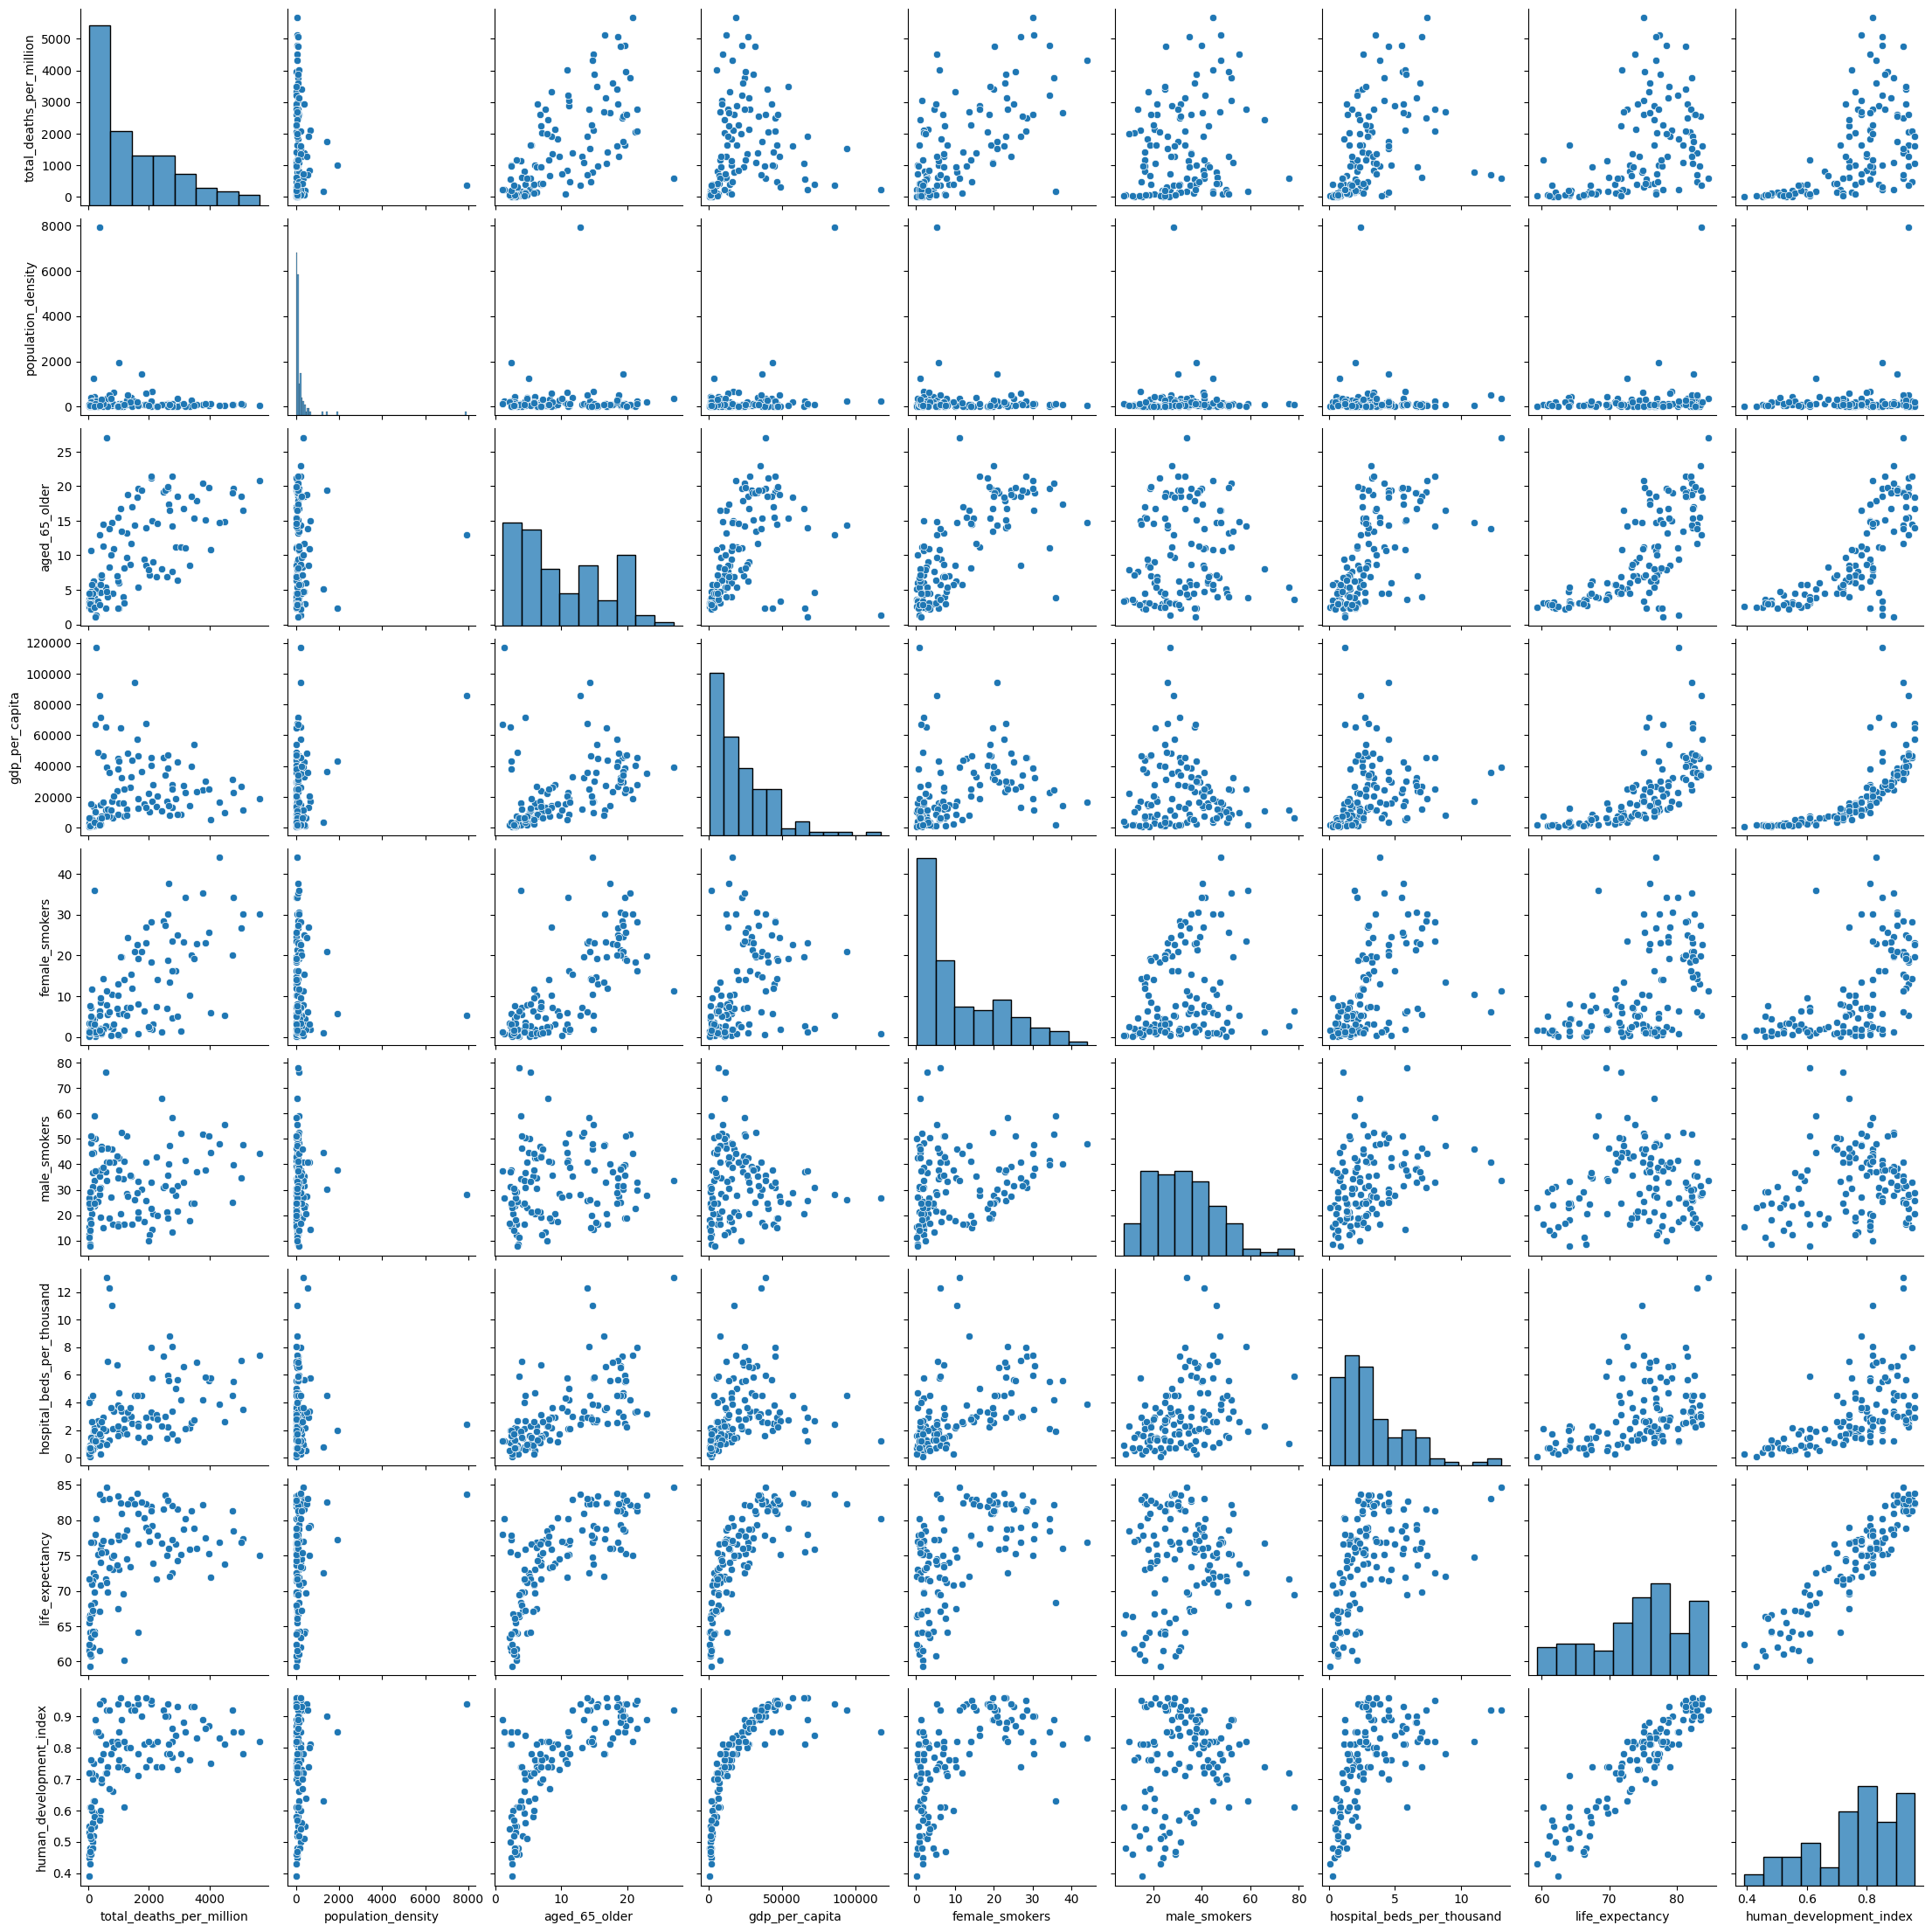

In [16]:
sns.pairplot(df_vars)
pass

We see that total deaths per million surprisingly has positive correlation with variables like human development index, life expectancy, and hospital beds per thousand. There may be some confounding variables, like more developed countries being able to report deaths more accurately. One correlation that does make sense is that total deaths per million is positively correlated with the number of people aged 65 or older; the elderly are more vulnerable to Covid.